# Проект: Статистический анализ данных

# Анализ сервиса аренды самокатов GoFast

Мне предоставленны данные от сервиса аренды самокатов GoFast, о некоторых пользователях из нескольких городов, а также данные об  их поездках.

Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением. Сервисом можно пользоваться:
- без подписки
   - абонентская плата отсутствует;
   - стоимость одной минуты поездки — 8 рублей;
   - стоимость старта (начала поездки) — 50 рублей;

- с подпиской Ultra
   - абонентская плата — 199 рублей в месяц;
   - стоимость одной минуты поездки — 6 рублей;
   - стоимость старта — бесплатно.


**Цель:**

Проанализировать данные и проверить некоторые гипотезы, которые могут помочь бизнесу вырасти.

**Ход работы:**

**1. Загрузка данных**

    Получаю данные из файлов: /users_go.csv/ - Пользователи, /rides_go.csv/ - Поездки, /subscriptions_go.csv/ - Подписки.
    
    Изучаю исходные данные в каждом датафрейме: названия, формат, определяю объем работы, который надо провести в следующем этапе. 


**2. Предобработка данных**

    При необходимости переводим столбцы к необходимому формату.
    
    Проверяю на пропуски, дубликаты явные/ не явные.
    
**3. Исследовательский анализ данных**

    Описываю и вузуализирую общую информацию о пользователях и поездках, а именно зависимости одних данных от других.
    
**4. Объединение данных**

    Объединяю данные о пользователях, поездках и подписках в один датафрейм. 

**5. Подсчет выручки**
  
    Провожу необходимые расчеты для более точного представлени данных.
     
**6. Проверка гипотез**

    Гипотезы, которые могут помочь бизнесу вырасти.
    
**7. Вывод**



Итого, будут проведены 7 этапов, в ходе, которых будет произведен анализ данных, по окончанию каждого этапа будет подведен промежуточный вывод. 

# Открытие файла и изучение общей информации

In [1]:
#импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy import stats as st
from scipy.stats import binom

## Пользователи

In [2]:
data_users = pd.read_csv('/datasets/users_go.csv')
data_users.head()# выводим первые 10 строк таблицы

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [3]:
data_users.info()#получаем общую информацию о таблице

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


## Поездки

In [4]:
data_rides = pd.read_csv('/datasets/rides_go.csv')
data_rides.head()# выводим первые 10 строк таблицы

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [5]:
data_rides.info()#получаем общую информацию о таблице

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


## Подписки

In [6]:
data_subscriptions = pd.read_csv('/datasets/subscriptions_go.csv')
data_subscriptions.head()# выводим первые 10 строк таблицы

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [7]:
data_subscriptions.info()#получаем общую информацию о таблице

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


**Вывод:**

Все таблицы открыты, названия каждого столбца написанны в корректном формате "змеиный_стиль", формат данных корректный у всех данных, кроме столбца "дата", этот столбец приведем к корректному формату в следующем этапе.

Также рассмторим формат данных столбца продолжительности поездки, скорее всего для дальнейшей работы придется округлить значения.

# Предобработка данных

In [8]:
data_rides['date'].head()#вывожу столбец, чтобы изучить его еще раз и начать с ним работу.

0    2021-01-01
1    2021-01-18
2    2021-04-20
3    2021-08-11
4    2021-08-28
Name: date, dtype: object

In [9]:
#data_rides['date'].astype('datetime64')

In [10]:
#Меняю формат столбца с object на datetime64
#data_rides['date'] = pd.to_datetime(data_rides['date'], format='%Y-%m-%dT%H:%M:%S')
data_rides['date'] = pd.to_datetime(data_rides['date'], format='%Y-%m-%d')
data_rides['date'].head()#вовожу столбец еще раз, чтобы убедиться в формате.

0   2021-01-01
1   2021-01-18
2   2021-04-20
3   2021-08-11
4   2021-08-28
Name: date, dtype: datetime64[ns]

In [11]:
#Добавляю новый столбец в таблицу
#солбец "месяц" совершенной поездки
data_rides['month'] = data_rides['date'].dt.month 
data_rides.head()

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


In [12]:
data_users.isna().sum()#находим пропуски в столбцах

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

In [13]:
data_rides.isna().sum()#находим пропуски в столбцах

user_id     0
distance    0
duration    0
date        0
month       0
dtype: int64

In [14]:
data_subscriptions.isna().sum()#находим пропуски в столбцах

subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

In [15]:
#проверяем на дубликаты
print('Количество дубликатов в датафрейме Пользователи: ', data_users.duplicated().sum())

Количество дубликатов в датафрейме Пользователи:  31


In [16]:
data_users = data_users.drop_duplicates().reset_index(drop = True)#удаление дубликатов

In [17]:
# Проверка на наличие дубликатов после их удаления
print('Количество дубликатов в датафрейме Пользователи: ', data_users.duplicated().sum())

Количество дубликатов в датафрейме Пользователи:  0


In [18]:
#проверяем на дубликаты
print('Количество дубликатов в датафрейме Поездки: ', data_rides.duplicated().sum())

Количество дубликатов в датафрейме Поездки:  0


In [19]:
#проверяем на дубликаты
print('Количество дубликатов в датафрейме Подписки: ', data_subscriptions.duplicated().sum())

Количество дубликатов в датафрейме Подписки:  0


In [20]:
# Проверка на не явные дубликаты
set(data_users['name'].unique())

{'Агата',
 'Аделина',
 'Адель',
 'Айдар',
 'Александр',
 'Александра',
 'Алексей',
 'Алина',
 'Алиса',
 'Алия',
 'Алла',
 'Альберт',
 'Альбина',
 'Алёна',
 'Амалия',
 'Амина',
 'Амир',
 'Анастасия',
 'Анатолий',
 'Ангелина',
 'Андрей',
 'Анжелика',
 'Анна',
 'Антон',
 'Антонина',
 'Ариана',
 'Арина',
 'Арсен',
 'Арсений',
 'Артемий',
 'Артур',
 'Артём',
 'Богдан',
 'Борис',
 'Вадим',
 'Валентина',
 'Валерий',
 'Валерия',
 'Варвара',
 'Василий',
 'Василина',
 'Василиса',
 'Вера',
 'Вероника',
 'Виктор',
 'Виктория',
 'Виолетта',
 'Виталий',
 'Виталина',
 'Влад',
 'Влада',
 'Владимир',
 'Владислав',
 'Владислава',
 'Всеволод',
 'Вячеслав',
 'Галина',
 'Георгий',
 'Герман',
 'Глеб',
 'Гордей',
 'Григорий',
 'Давид',
 'Дамир',
 'Даниил',
 'Данил',
 'Данила',
 'Даниэль',
 'Дарина',
 'Дарья',
 'Демид',
 'Денис',
 'Диана',
 'Дмитрий',
 'Ева',
 'Евгений',
 'Евгения',
 'Егор',
 'Екатерина',
 'Елена',
 'Елизавета',
 'Елисей',
 'Есения',
 'Жанна',
 'Зарина',
 'Захар',
 'Злата',
 'Иван',
 'Игнат',

In [21]:
# Проверка на не явные дубликаты
set(data_users['city'].unique())

{'Екатеринбург',
 'Краснодар',
 'Москва',
 'Омск',
 'Пятигорск',
 'Ростов-на-Дону',
 'Сочи',
 'Тюмень'}

In [22]:
#переводим солбец продолжительности поездки в целочисленный формат, 
#так как время должно быть указанно в минутах,
#и также для дальнейшего анализа, нам потребуются данные в минутах.
data_rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
 4   month     18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 705.9 KB


In [23]:
#округление к ближайшему большему значению и изменение формата
data_rides['duration'] = np.ceil(data_rides['duration']).astype('int')

In [24]:
#данные в столбце расстояния приводим к записи - два значения после точки.
data_rides['distance'] = data_rides['distance'].round(2)

In [25]:
data_rides.head()#проверяем, что все действия прошли удачно.

,user_id,distance,duration,date,month
0,1,4409.92,26,2021-01-01,1
1,1,2617.59,16,2021-01-18,1
2,1,754.16,7,2021-04-20,4
3,1,2694.78,19,2021-08-11,8
4,1,4028.69,27,2021-08-28,8


**Вывод:**

На данном этапе был изменен формат у столбцов **"date"** с *float64* на *int*, **"duration"** с *object* на *datetime64*.

Пропуски в датафреймах не обнаружены.

Был обнаружен 31 дубликат в датафрейме Пользователи, дубликаты были удалены. 
Явных дубликатов не обнаруженно.


Был добавлен новый столбец в датафрейме Поездки - "Месяц" поездки.


Данные в столбце **duration** привели к записи - двум знаком после точки.

# Исследовательский анализ данных

**КОЛИЧЕСТВО ПОЛЬЗОВАТЕЛЕЙ ПО ГОРОДАМ**

In [26]:
data_users.groupby('city').size().sort_values(ascending=False)
#группировка данных по горадам, чтобы увидеть количество пользовтелей в каждом городе, 
#сортируем данные по убыванию

city
Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
dtype: int64

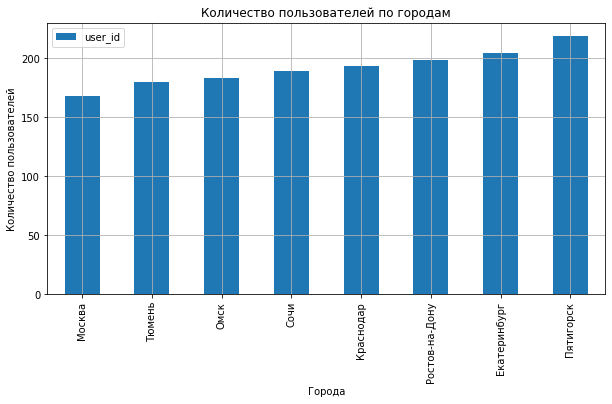

In [27]:
#строим столбчатую диаграмму
data_users.pivot_table(index='city', values='user_id', aggfunc='count').sort_values(
    by='user_id', ascending=True).plot( kind='bar', grid=True, figsize=(10, 5))
plt.title('Количество пользователей по городам')
plt.ylabel('Количество пользователей')
plt.xlabel('Города')

plt.show()

<AxesSubplot:title={'center':'Распределение пользователей по городам'}, ylabel='city'>

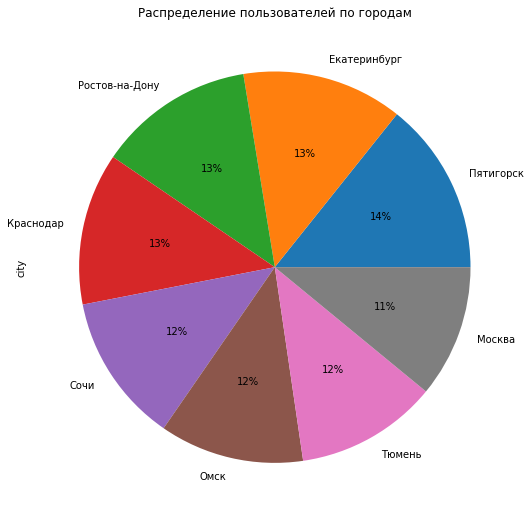

In [28]:
data_users['city'].value_counts().plot(
    kind = 'pie', 
    y = data_users['city'],
    autopct = '%1.0f%%',
    figsize=(9,9), 
    title = 'Распределение пользователей по городам')

В Пятигорске находится дольше всего пользователей, следующими по количеству идут: Екатеринбург, Ростов-на-Дону, Краснодар, за ними  Сочи, Минск, Тюмень. Наименьшее количество пользователей находится в Москве.

**КОЛИЧЕСТВО ПОЛЬЗОВАТЕЛЕЙ С ПОДПИСКОЙ И БЕЗ**

<AxesSubplot:title={'center':'Распределение пользователей по подписке'}, ylabel='subscription_type'>

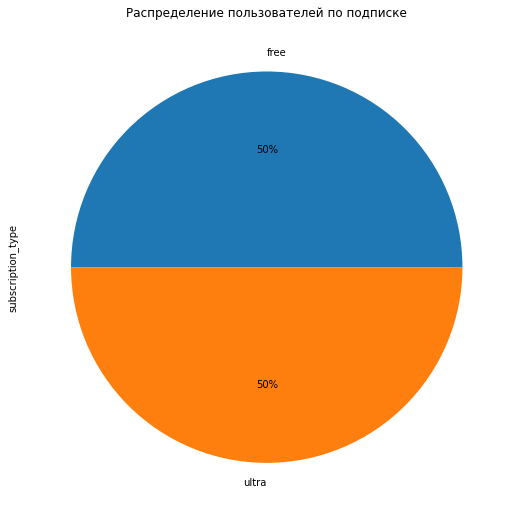

In [29]:
data_subscriptions['subscription_type'].value_counts().plot(
    kind = 'pie', 
    y = data_subscriptions['subscription_type'],
    autopct = '%1.0f%%',
    figsize=(9,9), 
    title = 'Распределение пользователей по подписке')

Количество пользователей с подпиской и без - равны.

In [30]:
data_users['subscription_type'].value_counts()

free     835
ultra    699
Name: subscription_type, dtype: int64

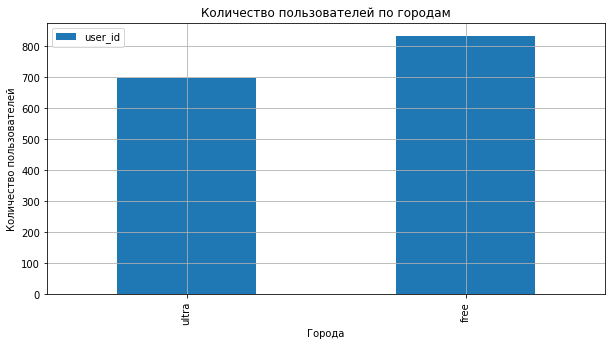

In [31]:
data_users.pivot_table(index='subscription_type', values='user_id', aggfunc='count').sort_values(
    by='user_id', ascending=True).plot( kind='bar', grid=True, figsize=(10, 5))
plt.title('Количество пользователей по городам')
plt.ylabel('Количество пользователей')
plt.xlabel('Города')

plt.show()

Количество пользователей с подпиской меньше, чем количествл пользователей без подписки.

**ЗАВИСИМОСТЬ ПОЛЬЗОВАТЕЛЕЙ ОТ ВОЗРАСТА**

Text(0, 0.5, 'Количество пользователей')

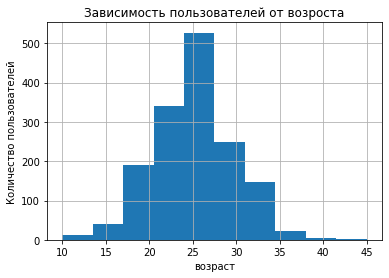

In [32]:
data_users['age'].hist(bins=10, range=(10,45))
plt.title('Зависимость пользователей от возроста')
plt.xlabel('возраст')
plt.ylabel('Количество пользователей')

In [33]:
data_users.groupby('age').size().sort_values(ascending=False)
#группировка пользователей по возрасту 
#сортируем данные по убыванию

age
25    145
24    132
26    131
23    129
27    119
22    119
28    112
21     93
20     71
30     68
29     68
31     48
19     47
18     46
32     41
33     39
17     26
34     19
16     19
35     15
15     13
14      9
13      8
36      6
12      4
38      3
37      2
39      1
43      1
dtype: int64

Наибольшее количество пользователей в диапозоне от 21 до 25 лет. Наименьшее до 15 лет и после 35.

**ЗАВИСИМОСТЬ КОЛИЧЕСТВА ПОЕЗДОК ОТ РАССТОЯНИЯ**

In [34]:
data_rides['distance'].describe()#проводим описательную статистику столбца.

count    18068.000000
mean      3070.659992
std       1116.831222
min          0.860000
25%       2543.227500
50%       3133.610000
75%       3776.220000
max       7211.010000
Name: distance, dtype: float64

Text(0, 0.5, 'Количество поездок')

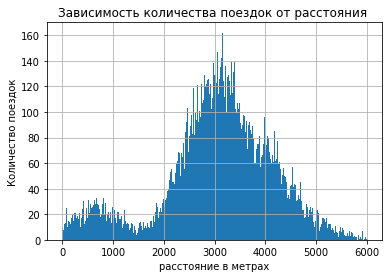

In [35]:
data_rides['distance'].hist(bins=400, range=(1,6000))
plt.title('Зависимость количества поездок от расстояния ')
plt.xlabel('расстояние в метрах')
plt.ylabel('Количество поездок')

Наибольшее количество поездок совершают на расстоянии от 2900 до 3300 метров. 

**ЗАВИСИМОСТЬ КОЛИЧЕСТВА ПОЕЗДОК ОТ ВРЕМЕНИ**

In [36]:
data_rides['duration'].describe()#проводим описательную статистику столбца.

count    18068.000000
mean        18.303520
std          6.094928
min          1.000000
25%         14.000000
50%         18.000000
75%         22.000000
max         41.000000
Name: duration, dtype: float64

Text(0, 0.5, 'Количество поездок')

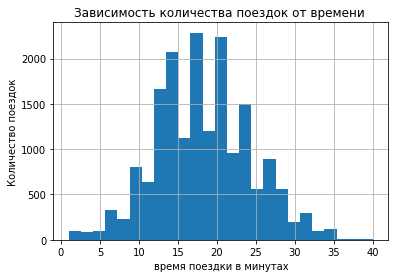

In [37]:
data_rides['duration'].hist(bins=25, range=(1,40))
plt.title('Зависимость количества поездок от времени ')
plt.xlabel('время поездки в минутах')
plt.ylabel('Количество поездок')

Исходя из гистограммы есть три "пика" следовательно, пользователи берут самокат на 12 - 15, 17 - 18, 20-22 минут.

Однако, есть поездки по 1 минуте, посмотирим их количество.

In [38]:
print('Количество поездок, время которых заняло по 1 минуте:', len(data_rides.query('duration == 1')))

Количество поездок, время которых заняло по 1 минуте: 95


95 поездок, продолжительность которых минута - навряд ли может быть, скорее всего это анамальное значение. 95 от 18065 составляет 0.53%, на работу в дальнейшем не повлияет, поэтому на данном этапе трогать не будем.

**ИЗУЧИМ ЗАВИСИМОСТЬ КОЛИЧЕСТВО ПОЕЗДОК ОТ СКОРОСТИ**

Допустимая скорость для электрических самокатов не выше 25 км/час = 416 метр/мин

In [39]:
#проверим скорость пользователей.
speed = data_rides['distance']/data_rides['duration'] 

In [40]:
speed.describe()#проводим описательную статистику столбца.

count    18068.000000
mean       197.376146
std        366.031245
min          0.078182
25%        132.087171
50%        166.175932
75%        208.556523
max       7211.010000
dtype: float64

Максимальная скорость 7211 метр/мин - навряд ли может такое быть. Проверим это в следующих действиях. 

In [41]:
#выводим первые строки данных о скорости отсортированных по убыванию.
speed.sort_values(ascending=False).head()

16309    7211.01
17242    6724.93
11385    6601.20
13701    6414.52
14574    6316.57
dtype: float64

In [42]:
#посмотрим сколько значений больше, чем 400 метр/мин
print('Количество значений больше 400 метр/мин: ', len(data_rides.query('distance/duration >= 400 ')))

Количество значений больше 400 метр/мин:  100


Text(0, 0.5, 'Количество поездок')

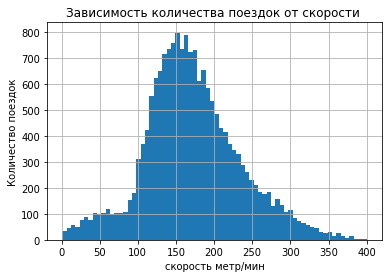

In [43]:
#строим гистограмму, отсеяв все значения, которые больше 400 метр/мин
speed.hist(bins=70, range=(1,400))
plt.title('Зависимость количества поездок от скорости ')
plt.xlabel('скорость метр/мин')
plt.ylabel('Количество поездок')

Наибольшее количество пользователей едут со скоростью 140 - 160 метр/мин. 

Text(0, 0.5, 'Количество поездок')

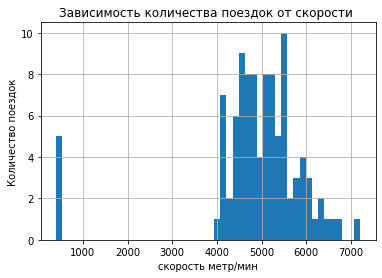

In [44]:
#постоим гистограмму для скорости больше 400 метр/мин
speed.hist(bins=50, range=(400,7212))
plt.title('Зависимость количества поездок от скорости ')
plt.xlabel('скорость метр/мин')
plt.ylabel('Количество поездок')

Тут видно,что появились значения скоростей 4000 - 7000 метр/мин. Скорее всего был сбой в программе, от этого и появились такие значения. 

Таких значений не так много, на дальнейшее исследование не повлияет.

**Вывод:**
После проведения анализа данных, были получены следующие результаты:

    - В Пятигорске находится дольше всего пользователей, следующими по количеству идут: Екатеринбург, Ростов-на-Дону, Краснодар,за идут Сочи, Мминск, Тюмень. Наименьшее количество пользователей находится в Москве.
    - Количество пользователей без подписки меньше, чем количество пользователей с подпиской.
    - Наибольшее количество пользователей в диапозоне от 21 до 25 лет. Наименьшее до 15 лет и после 35.
    - Наибольшее количество поездок совершают на расстоянии от 2900 до 3300 метров.
    - Пользователи берут самокат на 12 - 15, 17 - 18, 20-22 минут.
    - Найдена аномалия в скоростях пользователей и времени поездки.
    - Наибольшее количество пользователей едут со скоростью 140 - 160 метр/мин.

# Объединение данных

In [45]:
#объединяем таблицы
#создаем новую таблицу data
#объединяем таблицы Пользователи и Подписки по типу подписки.
data = pd.merge(data_users, data_subscriptions, on='subscription_type')
#объединяем уже новую таблицу с таблицеу Поездки по номеру пользователя.
data = pd.merge(data_rides, data, on='user_id')
data.head()

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4409.92,26,2021-01-01,1,Кира,22,Тюмень,ultra,6,0,199
1,1,2617.59,16,2021-01-18,1,Кира,22,Тюмень,ultra,6,0,199
2,1,754.16,7,2021-04-20,4,Кира,22,Тюмень,ultra,6,0,199
3,1,2694.78,19,2021-08-11,8,Кира,22,Тюмень,ultra,6,0,199
4,1,4028.69,27,2021-08-28,8,Кира,22,Тюмень,ultra,6,0,199


In [46]:
data.info()#получаем общую информацию о таблице

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18068 entries, 0 to 18067
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   distance           18068 non-null  float64       
 2   duration           18068 non-null  int64         
 3   date               18068 non-null  datetime64[ns]
 4   month              18068 non-null  int64         
 5   name               18068 non-null  object        
 6   age                18068 non-null  int64         
 7   city               18068 non-null  object        
 8   subscription_type  18068 non-null  object        
 9   minute_price       18068 non-null  int64         
 10  start_ride_price   18068 non-null  int64         
 11  subscription_fee   18068 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(7), object(3)
memory usage: 1.8+ MB


**ТАБЛИЦА ПОЛЬЗОВАТЕЛЕЙ С ПОДПИСКОЙ**

In [47]:
#созание таблицы пользователей с подпиской
data_ultra = data[data['subscription_type'] == 'ultra']
data_ultra.head()

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4409.92,26,2021-01-01,1,Кира,22,Тюмень,ultra,6,0,199
1,1,2617.59,16,2021-01-18,1,Кира,22,Тюмень,ultra,6,0,199
2,1,754.16,7,2021-04-20,4,Кира,22,Тюмень,ultra,6,0,199
3,1,2694.78,19,2021-08-11,8,Кира,22,Тюмень,ultra,6,0,199
4,1,4028.69,27,2021-08-28,8,Кира,22,Тюмень,ultra,6,0,199


In [48]:
data_ultra['distance'].describe()

count    6500.000000
mean     3115.445431
std       836.895369
min       244.210000
25%      2785.447500
50%      3148.640000
75%      3560.577500
max      5699.770000
Name: distance, dtype: float64

Text(0, 0.5, 'Количество поездок')

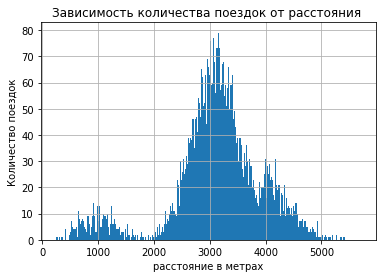

In [49]:
data_ultra['distance'].hist(bins=400, range=(243,5700))
plt.title('Зависимость количества поездок от расстояния ')
plt.xlabel('расстояние в метрах')
plt.ylabel('Количество поездок')

Пользователи с подпиской в среднем проезжают расстояние в 3115 метра.

In [50]:
data_ultra['duration'].describe()

count    6500.000000
mean       19.037692
std         5.577439
min         4.000000
25%        15.000000
50%        19.000000
75%        22.000000
max        41.000000
Name: duration, dtype: float64

Text(0, 0.5, 'Количество поездок')

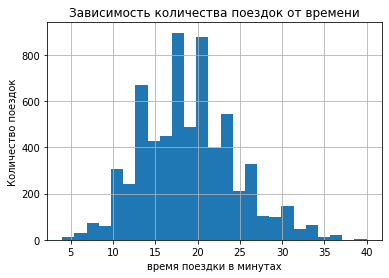

In [51]:
data_ultra['duration'].hist(bins=25, range=(4,40))
plt.title('Зависимость количества поездок от времени')
plt.xlabel('время поездки в минутах')
plt.ylabel('Количество поездок')

Большинство пользователи с подпиской проводят время в поездке 17-18, 20-22 мин.

**ТАБЛИЦА ПОЛЬЗОВАТЕЛЕЙ БЕЗ ПОДПИСКИ**

In [52]:
#созание таблицы пользователей с подпиской
data_free = data[data['subscription_type'] == 'free']
data_free.head()

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
6500,700,2515.69,15,2021-01-02,1,Айдар,22,Омск,free,8,50,0
6501,700,846.93,17,2021-02-01,2,Айдар,22,Омск,free,8,50,0
6502,700,4004.43,21,2021-02-04,2,Айдар,22,Омск,free,8,50,0
6503,700,1205.91,10,2021-02-10,2,Айдар,22,Омск,free,8,50,0
6504,700,3047.38,18,2021-02-14,2,Айдар,22,Омск,free,8,50,0


In [53]:
data_free['distance'].describe()

count    11568.000000
mean      3045.495284
std       1246.173810
min          0.860000
25%       2366.560000
50%       3114.650000
75%       3905.695000
max       7211.010000
Name: distance, dtype: float64

Text(0, 0.5, 'Количество поездок')

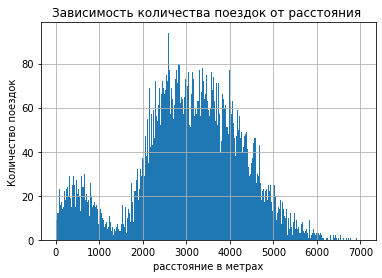

In [54]:
data_free['distance'].hist(bins=400, range=(1,7000))
plt.title('Зависимость количества поездок от расстояния ')
plt.xlabel('расстояние в метрах')
plt.ylabel('Количество поездок')

Большинство пользователей без подписки поезжают от 2000 до 4000 метров.

In [55]:
data_free['duration'].describe()

count    11568.000000
mean        17.890992
std          6.330250
min          1.000000
25%         13.000000
50%         18.000000
75%         22.000000
max         35.000000
Name: duration, dtype: float64

Text(0, 0.5, 'Количество поездок')

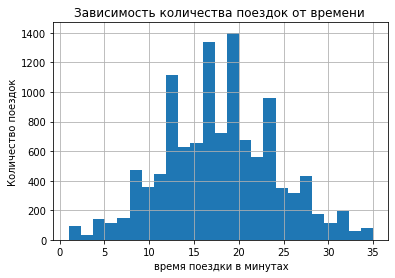

In [56]:
data_free['duration'].hist(bins=25, range=(1,35))
plt.title('Зависимость количества поездок от времени ')
plt.xlabel('время поездки в минутах')
plt.ylabel('Количество поездок')

Большинство пользователи без подписки проводят время в поездке 11-12, 17-20 мин.

**ОБЪЕДИНЕНИЕ ГИСТОГРАММ ДЛЯ НАГЛЯДНОГО СРАВНЕНИЯ**

***Зависимость количества поездок от расстояния*** 

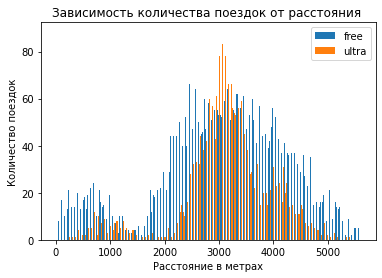

In [57]:
plt.hist([data_free['distance'], data_ultra['distance']], bins=400, range=(1,5600), label=['free', 'ultra'])
plt.legend(loc='upper right')
plt.title('Зависимость количества поездок от расстояния ')
plt.xlabel('Расстояние в метрах')
plt.ylabel('Количество поездок')
plt.show()

Пользователи с подпиской проезжают большее расстояние, но с маленьким размахом.
Пользователи без подписки проезжают меньшее расстояние, но с большим размахом.

***Зависимость количества поездок от времени***

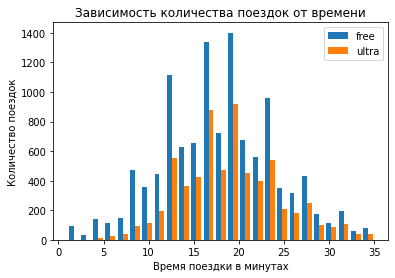

In [58]:
plt.hist([data_free['duration'], data_ultra['duration']], bins=25, range=(1,35), label=['free', 'ultra'])
plt.legend(loc='upper right')
plt.title('Зависимость количества поездок от времени')
plt.xlabel('Время поездки в минутах')
plt.ylabel('Количество поездок')
plt.show()

время пользование самокатов у пользователей с подпиской чуть больше, чем у пользователей без подписки, однако с меньшим размахом (меньше пользователей)

**Вывод:**

Были созданы две новые таблицы "Пользователи с подпиской" и "Пользователи без подписки". Были поостроины гистограммы зависисмости количества поездок от расстояния и зависисимости количества поездок от времени,исходя из них, были полученны слудующие данные:
        
        - Пользователи с подпиской проезжают большее расстояние, но с маленьким размахом.
        - Пользователи без подписки проезжают меньшее расстояние, но с большим размахом.
        - В средне пользователи с подпиской проезжают - 3115 метров,а пользователи без подписки - 3045 метров.
        - Среднее время поездки с подпиской - 19 минут, без подписки - 17 минут.
       
       
        - Большинство пользователи с подпиской проводят время в поездке 17-18, 20-22 мин.
        - Большинство пользователи без подписки проводят время в поездке 11-12, 17-20 мин.
        - Среднее время поездки с подпиской - 19 минут, без подписки - 17 минут.
        
Пользователи с подпиской дольше и больше пользуются самокатами, но таких пользователей меньше, чем пользователей без подписки

# Подсчёт выручки

Создание датафрейм с агрегированными данными о поездках на основе датафрейма с объединёнными данными. Находим суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц.

In [59]:
info_users_months = data.pivot_table(
    index=('user_id', 'month'),
    values=(
        'distance', 
        'duration', 
        'minute_price',
        'start_ride_price', 
        'subscription_fee',
        'subscription_type'
    ), 
    aggfunc=({'distance':{'count', 'sum'}, 
             'duration':'sum',
             'minute_price': 'mean',
             'start_ride_price':'mean',
             'subscription_fee':'mean',
             'subscription_type':'first'})
)
info_users_months.columns = [
    'count', 'distance', 
    'duration', 
    'minute_price',
    'start_ride_price', 
    'subscription_fee',
'subscription_type']
info_users_months.head(10)

count  distance  duration  minute_price  start_ride_price  \
user_id month                                                              
1       1          2   7027.51        42             6                 0   
        4          1    754.16         7             6                 0   
        8          2   6723.47        46             6                 0   
        10         2   5809.91        32             6                 0   
        11         3   7003.50        56             6                 0   
        12         2   6751.63        28             6                 0   
2       3          3  10187.73        63             6                 0   
        4          2   6164.39        40             6                 0   
        6          1   3255.34        14             6                 0   
        7          2   6780.73        48             6                 0   

               subscription_fee subscription_type  
user_id month                                      
1       1                   199             ultra  
        4                   199             ultra  
        8                   199             ultra  
        10                  199             ultra  
        11                  199             ultra  
        12                  199             ultra  
2       3                   199             ultra  
        4                   199             ultra  
        6                   199             ultra  
        7                   199             ultra

Добавление столбца в датафрейм с помесячной выручкой, которую принёс каждый пользователь.

In [60]:
info_users_months['monthly_revenue'] = (
info_users_months['start_ride_price']*info_users_months['count']+
info_users_months['minute_price']*info_users_months['duration']+
info_users_months['subscription_fee'])

info_users_months.head()

count  distance  duration  minute_price  start_ride_price  \
user_id month                                                              
1       1          2   7027.51        42             6                 0   
        4          1    754.16         7             6                 0   
        8          2   6723.47        46             6                 0   
        10         2   5809.91        32             6                 0   
        11         3   7003.50        56             6                 0   

               subscription_fee subscription_type  monthly_revenue  
user_id month                                                       
1       1                   199             ultra              451  
        4                   199             ultra              241  
        8                   199             ultra              475  
        10                  199             ultra              391  
        11                  199             ultra              535

# Проверка гипотез

**Тратят ли пользователи с подпиской больше времени на поездки?**

Н0: Средняя продолжительность поездки с подпиской и без равны.

Н1: Средняя продолжительность поездки по подписке больше,чем продолжительность без подписки.

In [61]:
results = st.ttest_ind(
    data_ultra['duration'], 
    data_free['duration'], 
    equal_var=True, 
    alternative='greater')
print(results.pvalue)

alpha = 0.05
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

2.4959453720736625e-34
Отвергаем нулевую гипотезу


**Вывод:**

Нулевая гипотеза отвергнута, соответственно у пользователей с подпиской средняя продолжительность поездки больше, чем у пользователей без подписки.

**Среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров?**

Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката.

Н0: Среднее расстояние с подпиской равно 3130 метров

Н1: Средняя расстояние с подпиской больше 3130 метров.

In [62]:
distance = 3130

results = st.ttest_1samp(
    data_ultra['distance'], 
    distance,
    alternative='greater')

print(results.pvalue)

alpha = 0.05
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

0.9195362605842414
Не получилось отвергнуть нулевую гипотезу


**Вывод:**

Не получилось отвергнуть нулевую гипотезу, следовательно среднее расстояние у пользователей с подпиской не превышает расстояние оптимальное с точки зрения износа самоката.

**Будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.**

Н0: Помесячная выручка у пользователей с подпиской и без равна.

Н1: Помесячная выручка у пользователей с подпиской больше, чем у пользователей без подписки.

In [63]:
results = st.ttest_ind(
    info_users_months.loc[info_users_months['subscription_fee'] > 0, 'monthly_revenue'], 
    info_users_months.loc[info_users_months['subscription_fee'] == 0, 'monthly_revenue'], 
    equal_var=True, 
    alternative='greater')
print(results.pvalue)

alpha = 0.05
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

1.8850394384715216e-31
Отвергаем нулевую гипотезу


**Техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест вам понадобился бы для проверки этой гипотезы?**

Файл с данными до обновленния и после него, получается это две зависимые выборки (зависят от обновления). Если проверить гипотезу о равенстве среднего значения генеральной совокупностидо и после изменения, то воспульзуемся методом **scipy.stats.ttest_rel** Аргументы: набор данных до обновленния и после.

если передать методу значения аргумента alternative: 'two_sided' - то будет проверена двусторонняя гипотеза,  а если 'less' или 'greater', то левосторонняя или правосторонняя соотвественно.

гипотезы:
До обновления сервера среднее значение обращений в тех поддержку больше, чем среднее значение обращений в тех поддержку до обновления сервера.

Среднее обращение в тех поддержку до обновления и после обнавления равны.

**Вывод:**

Нулевая гипотеза отвергнута, соответственно у пользователей с подпиской средняя помесячная выручка больше, чем у пользователей без подписки.

**Заключение гипотез:**

пользователи с подпиской дольше пользуются самокатами, не привышают расстояние оптимальное с точки зрения износа самоката и приносят большую помесячную вырочку, следовательно для бизнеса выгоднее пользователи с подпиской.

**Вывод по анализу данных сервиса по аренде самокатов GoFast:**


**Цель:**

Проанализировать данные и проверить некоторые гипотезы, которые могут помочь бизнесу вырасти.

**В ходе работы были пройдены следующие этапы:**

**1. Загрузка данных**

    Получаю данные из файлов: /users_go.csv/ - Пользователи, /rides_go.csv/ - Поездки, /subscriptions_go.csv/ - Подписки.
    
    Изучаю исходные данные в каждом датафрейме: названия, формат, определяю объем работы, который надо провести в следующем этапе. 


**2. Предобработка данных**

    На данном этапе был изменен формат у столбцов **"date"** с *float64* на *int*, **"duration"** с *object* на *datetime64*.
    Пропуски в датафреймах не обнаружены.
    Был обнаружен 31 дубликат в датафрейме Пользователи, дубликаты были удалены. 
    Явных дубликатов не обнаруженно.
    Был добавлен новый столбец в датафрейме Поездки - "Месяц" поездки.
    Данные в столбце **duration** привели к записи - двум знаком после точки.
    
**3. Исследовательский анализ данных**

     В Пятигорске находится дольше всего пользователей, следующими по количеству идут: Екатеринбург, Ростов-на-Дону, Краснодар,за идут Сочи, Мминск, Тюмень. Наименьшее количество пользователей находится в Москве.
    Количество пользователей с подпиской и без - равны.
    Наибольшее количество пользователей в диапозоне от 21 до 25 лет. Наименьшее до 15 лет и после 35.
    Наибольшее количество поездок совершают на расстоянии от 2900 до 3300 метров.
    Пользователи берут самокат на 12 - 15, 17 - 18, 20-22 минут.
    Найдена аномалия в скоростях пользователей и времени поездки.
    Наибольшее количество пользователей едут со скоростью 140 - 160 метр/мин.
    
**4. Объединение данных**

    Были созданы две новые таблицы "Пользователи с подпиской" и "Пользователи без подписки". Были поостроины гистограммы зависисмости количества поездок от расстояния и зависисимости количества поездок от времени,исходя из них, были полученны слудующие данные:
        
        - Пользователи с подпиской проезжают большее расстояние, но с маленьким размахом.
        - Пользователи без подписки проезжают меньшее расстояние, но с большим размахом.
        - В средне пользователи с подпиской проезжают - 3115 метров,а пользователи без подписки - 3045 метров.
        - Среднее время поездки с подпиской - 19 минут, без подписки - 17 минут.
       
        - Большинство пользователи с подпиской проводят время в поездке 17-18, 20-22 мин.
        - Большинство пользователи без подписки проводят время в поездке 11-12, 17-20 мин.
        - Среднее время поездки с подпиской - 19 минут, без подписки - 17 минут.
        
Пользователи с подпиской дольше и больше пользуются самокатами, но таких пользователей меньше, чем пользователей без подписки 

**5. Подсчет выручки**
  
    Создание датафрейм с агрегированными данными о поездках на основе датафрейма с объединёнными данными. Находим суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц.
    
    Добавление столбца в датафрейм с помесячной выручкой, которую принёс каждый пользователь.
     
**6. Проверка гипотез**

    Пользователи с подпиской дольше пользуются самокатами, не привышают расстояние оптимальное с точки зрения износа самоката и приносят большую помесячную вырочку, следовательно для бизнеса выгоднее пользователи с подпиской.
